# Trabajo Práctico N°8 del TPS: Modelos de Lenguaje y Sistema de Recomendación



Este trabajo práctico se divide en dos partes. En la primera se explora el modelo de lenguaje FastText: se utilizan sus representaciones vectoriales pre-entrenadas para implementar analogías semánticas entre países y capitales, y se visualizan dichas representaciones mediante PCA. En la segunda se diseña un sistema de recomendación de materias de FIUBA basado en filtrado colaborativo, entrenado por gradiente descendente.

Se empieza por cargar e importar las librerías que se utilizarán a lo largo de este trabajo práctico.

In [1]:
import importlib, subprocess, sys

if importlib.util.find_spec("fasttext") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fasttext-wheel"])

import os, gzip, shutil, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fasttext
from sklearn.decomposition import PCA

## 1. Modelo de Lenguaje


En esta sección se explora la capacidad semántica de un modelo de lenguaje pre-entrenado. La idea central es que, al entrenar una red neuronal para predecir palabras en contexto, las palabras quedan representadas como vectores en un espacio de alta dimensión donde la proximidad geométrica refleja similaridad semántica. Esto permite operar sobre significados mediante aritmética vectorial.

Se utilizan estas representaciones para resolver analogías del tipo *"A es a B como C es a ..."* y se visualiza la estructura del espacio mediante reducción de dimensionalidad con PCA.

### Contexto teórico

#### El problema de cómo representar palabras

Las redes neuronales trabajan con números. Una palabra como "king" no es un número, entonces hay que convertirla. Una solución simple es utilizar un one-hot vector (visto en TPs anteriores): si el vocabulario tiene $K$ palabras, "king" es un vector de $K$ dimensiones con un 1 en su posición y ceros en el resto. El problema es que si $K = 1.000.000$, cada palabra ocupa un vector de un millón de dimensiones para guardar básicamente un índice. Además, no captura ninguna relación semántica: "king" y "queen" son tan distintos como "king" y "banana".

#### Word2Vec: aprender representaciones del contexto

Word2Vec resuelve esto entrenando una red neuronal para predecir palabras vecinas. La observación clave es que palabras con significados similares aparecen en contextos similares: "king" y "queen" aparecen frecuentemente cerca de "throne", "crown", "royal". Esa regularidad estadística es lo que el modelo captura.

La arquitectura es simple: una red de una sola capa oculta con una matriz de pesos $W \in \mathbb{R}^{K \times 300}$. Cada fila de $W$ es el **embedding** de una palabra, un vector de 300 números que la describe. Al principio esos valores son aleatorios. El entrenamiento los va ajustando.

La tarea es: dada una palabra central, predecir sus vecinas dentro de una ventana de $\pm 2$ posiciones. Para cada par (central, vecina), la probabilidad predicha es:

$$P(\text{vecina} \mid \text{central}) = \sigma\!\left(\vec{v}_{\text{central}} \cdot \vec{v}_{\text{vecina}}\right)$$

donde $\sigma(x) = \frac{1}{1+e^{-x}}$ es la sigmoide, que convierte el producto escalar (qué tan alineados están los vectores) en una probabilidad entre 0 y 1. El ajuste que recibe cada vector en cada paso es:

$$\Delta \vec{v}_{\text{central}} = \alpha \cdot \underbrace{\bigl(1 - \sigma(\vec{v}_{\text{central}} \cdot \vec{v}_{\text{vecina}})\bigr)}_{\text{proporcional al error}} \cdot \underbrace{\vec{v}_{\text{vecina}}}_{\text{dirección del jalón}}$$

El jalón es proporcional al error actual: si los vectores ya están alineados, $\sigma \approx 1$ y el ajuste es casi nulo. Si están opuestos, $\sigma \approx 0$ y el ajuste es máximo. Es un sistema de retroalimentación: se corrige fuertemente cuando se está lejos y suave cuando se está cerca.

**Ejemplo concreto.** Se consideran dos oraciones del corpus:

> *"The king wore the **crown**"*  
> *"The **queen** wore the crown"*

Con ventana de $\pm 2$, la primera oración genera entre otros los pares *(king, crown)* y *(crown, king)*. Esto produce un jalón: $\vec{v}_{\text{king}}$ se mueve en dirección a $\vec{v}_{\text{crown}}$, y viceversa. La segunda oración genera *(queen, crown)* y *(crown, queen)*: $\vec{v}_{\text{queen}}$ también se acerca a $\vec{v}_{\text{crown}}$.

Ninguna oración generó el par *(king, queen)* directamente. Sin embargo, ambas palabras recibieron jalones hacia el mismo punto: *crown*. Como convergieron hacia la misma región, terminan cerca entre sí como efecto secundario. Ese mecanismo, repetido millones de veces con miles de palabras compartidas (throne, royal, realm...), es lo que hace que king y queen queden cerca en el espacio.

La palabra "the", en cambio, aparece en absolutamente todas las oraciones. Sus jalones vienen de todas las direcciones y se cancelan entre sí, dejando su vector en el centro del espacio, donde está cerca de todo y de nada. Por eso las *stop words* no aportan información discriminativa.

Tras millones de oraciones, las palabras que comparten contexto terminan con vectores similares, y las que aparecen en contextos distintos terminan en regiones distintas del espacio.

#### Lo que emerge: geometría semántica

El resultado sorprendente es que las relaciones semánticas se vuelven operaciones vectoriales. El ejemplo clásico:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

"King" y "queen" comparten vecinas de realeza (throne, crown, royal) pero difieren en vecinas de género (he/she, prince/princess). El modelo aprendió una dirección en $\mathbb{R}^{300}$ que separa géneros y otra que captura realeza. La resta cancela una y preserva la otra sin que nadie se lo haya enseñado explícitamente (es impresionante).

La métrica utilizada para medir proximidad entre vectores es la **similitud coseno**, que mide el ángulo entre dos vectores independientemente de su magnitud:

$$\text{sim}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \, \|\vec{v}\|}$$

El resultado está entre $[-1, 1]$: vale 1 si los vectores apuntan en la misma dirección, 0 si son perpendiculares, y $-1$ si son opuestos. Se prefiere sobre la distancia euclídea porque los embeddings de FastText no están normalizados, es decir, dos palabras frecuentes tendrán vectores de mayor norma que palabras raras, y la distancia euclídea confundiría esa diferencia de escala con diferencia semántica. El coseno la elimina al normalizar.

#### Limitación de Word2Vec → FastText

Word2Vec trata cada palabra como una unidad atómica. Si una palabra no apareció en el entrenamiento, no tiene embedding. Tampoco aprovecha que "run", "running" y "runner" comparten estructura morfológica.

**FastText** resuelve esto descomponiendo cada palabra en **n-gramas de caracteres**. Por ejemplo, "playing" se divide en `<pl`, `pla`, `lay`, `ayi`, `yin`, `ing`, `ng>`, y su embedding es la suma de los vectores de esos fragmentos:

$$\vec{v}_{\text{playing}} = \sum_{g \in \mathcal{G}(\text{playing})} \vec{z}_g$$

Esto tiene dos consecuencias: las palabras nuevas se construyen desde sus partes, y las palabras con raíces comunes ("run", "running", "runner") comparten n-gramas y por lo tanto reciben jalones en las mismas direcciones durante el entrenamiento, de esta manera, su similitud morfológica se refleja en el espacio vectorial. Todo lo demás (tarea, gradiente, convergencia) es idéntico a Word2Vec.

El modelo utilizado en este trabajo (`cc.en.300.bin`) fue entrenado por Facebook sobre 600 mil millones de tokens del Common Crawl en inglés. Internamente almacena dos tablas de embeddings de 300 dimensiones: una con ~2 millones de vectores de palabras y otra con ~2 millones de vectores de n-gramas. Al consultar una palabra, FastText suma ambas contribuciones; para palabras fuera del vocabulario, usa únicamente los n-gramas.



### (a) Carga del modelo FastText

In [2]:
MODEL_GZ  = "cc.en.300.bin.gz"
MODEL_BIN = "cc.en.300.bin"
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz"

if not os.path.exists(MODEL_BIN):
    if not os.path.exists(MODEL_GZ):
        print("Descargando modelo (~4.2 GB)...")
        urllib.request.urlretrieve(URL, MODEL_GZ)
        print("Descarga completa.")
    print("Descomprimiendo...")
    with gzip.open(MODEL_GZ, "rb") as f_in, open(MODEL_BIN, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Listo.")
else:
    print(f"Modelo ya disponible: {MODEL_BIN}")

if "model" not in globals():
    model = fasttext.load_model(MODEL_BIN)
    print("Modelo cargado.")
else:
    print("Modelo ya en memoria.")


Descargando modelo (~4.2 GB)...
Descarga completa.
Descomprimiendo...
Listo.
Modelo cargado.


#### Exploración del modelo

Antes de trabajar con las analogías, se analiza el espacio de embeddings cargado para ganar intuición sobre su estructura. En particular, se verifica que los vectores tienen la forma esperada (300 dimensiones con valores de magnitud moderada), se contrasta la similitud coseno entre pares de palabras con distintas relaciones semánticas (desde palabras co-ocurrentes hasta palabras sin relación) y se comprueba empíricamente que la aritmética vectorial captura relaciones de género, confirmando el comportamiento teórico descrito en la sección anterior.

In [3]:
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 1. Dimensión y rango de valores de un embedding
v_king = model.get_word_vector("king")
print(f"Dimensión del embedding: {v_king.shape}")
print(f"Rango de valores: [{v_king.min():.3f}, {v_king.max():.3f}]")
print(f"Norma: {np.linalg.norm(v_king):.3f}")
print()

# 2. Similitud coseno entre pares con distintas relaciones semánticas
pares = [
    ("king",   "queen",   "mismo tema, género distinto"),
    ("king",   "throne",  "co-ocurrentes directos"),
    ("king",   "France",  "sin relación"),
    ("king",   "banana",  "sin relación"),
    ("Paris",  "London",  "ambas capitales europeas"),
    ("run",    "running", "misma raíz (FastText ventaja)"),
]
print("Similitudes coseno:")
print(f"{'Par':<30} {'Similitud':>10}  Relación")
print("-" * 65)
for w1, w2, desc in pares:
    s = cos_sim(model.get_word_vector(w1), model.get_word_vector(w2))
    print(f"{w1+' ↔ '+w2:<30} {s:>10.4f}  {desc}")
print()

# 3. Verificación de la aritmética vectorial: king - man + woman ≈ ?
query = model.get_word_vector("king") - model.get_word_vector("man") + model.get_word_vector("woman")
candidatos = ["queen", "king", "woman", "man", "princess", "monarch", "throne"]
print("king - man + woman → similitudes con candidatos:")
for c in candidatos:
    s = cos_sim(query, model.get_word_vector(c))
    print(f"  {c:<12} {s:.4f}")

Dimensión del embedding: (300,)
Rango de valores: [-0.275, 0.227]
Norma: 1.558

Similitudes coseno:
Par                             Similitud  Relación
-----------------------------------------------------------------
king ↔ queen                       0.7069  mismo tema, género distinto
king ↔ throne                      0.5728  co-ocurrentes directos
king ↔ France                      0.1797  sin relación
king ↔ banana                      0.1493  sin relación
Paris ↔ London                     0.5923  ambas capitales europeas
run ↔ running                      0.7398  misma raíz (FastText ventaja)

king - man + woman → similitudes con candidatos:
  queen        0.6543
  king         0.7287
  woman        0.0095
  man          -0.2743
  princess     0.4449
  monarch      0.4914
  throne       0.4458


**Análisis de resultados.** Los embeddings tienen dimensión 300 y norma ~1.558, lo que confirma que los vectores no están normalizados: la escala varía por palabra y no aporta información semántica. De ahí la necesidad del coseno.

La similitud coseno puede interpretarse como un índice de compatibilidad semántica: cuanto más alto, mayor la probabilidad de que las dos palabras compartan contexto en el corpus, es decir, de que el modelo las haya "visto juntas" con frecuencia. Los valores observados siguen el orden esperado:

| Par | Similitud | Interpretación |
|-----|-----------|----------------|
| run ↔ running | 0.7398 | morfológicamente idénticas (FastText) |
| king ↔ queen | 0.7069 | mismo dominio semántico, género distinto |
| Paris ↔ London | 0.5923 | ambas capitales europeas |
| king ↔ throne | 0.5728 | co-ocurrentes directos |
| king ↔ France | 0.1797 | sin relación directa |
| king ↔ banana | 0.1493 | sin relación |

Para la aritmética vectorial, el vector query $\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}}$ es aún más similar a king (0.7287) que a queen (0.6543), dado que el punto de partida es king y la corrección de género es una perturbación pequeña en $\mathbb{R}^{300}$. Excluyendo las palabras de entrada del ranking queen resulta el candidato más próximo, lo que valida empíricamente el comportamiento teórico.

Con el modelo cargado, se implementan las dos funciones auxiliares que se usarán a lo largo de la sección. `cosine_similarity(v, M)` calcula la similitud coseno entre el vector consulta $\vec{v}$ y cada fila $\vec{m}_i$ de la matriz $M$ de forma vectorizada: se normaliza $\vec{v}$ y cada fila de $M$, y se calcula el producto $\hat{M}\cdot\hat{v}$ en una sola operación matricial, sin bucles en Python. `analogy(A, B, C)` construye el vector consulta $\vec{q} = \vec{B} - \vec{A} + \vec{C}$, lo compara contra toda la base de datos usando `cosine_similarity`, excluye las palabras de entrada del ranking y devuelve los 3 candidatos más cercanos.

In [4]:
def cosine_similarity(v, M):
    """Similitud coseno entre el vector v y cada fila de la matriz M."""
    v_norm = v / np.linalg.norm(v)
    M_norm = M / np.linalg.norm(M, axis=1, keepdims=True)
    return M_norm @ v_norm


def analogy(A, B, C, top_k=3):
    """Resuelve la analogía A:B :: C:? usando aritmética vectorial.

    Construye q = v(B) - v(A) + v(C) y devuelve los top_k vecinos más
    cercanos en word_vectors, excluyendo las palabras de entrada.
    """
    query = (model.get_word_vector(B)
             - model.get_word_vector(A)
             + model.get_word_vector(C))
    sims = cosine_similarity(query, word_vectors)
    exclude = {A, B, C}
    ranked = sorted(
        [(words[i], sims[i]) for i in range(len(words)) if words[i] not in exclude],
        key=lambda x: x[1], reverse=True
    )
    return ranked[:top_k]


### (b) Analogías

Lo que se hace en esta sección es evaluarlo: se le plantean preguntas con respuesta conocida (¿la capital de England es London?) y se verifica si sus vectores capturan correctamente esa relación geográfica.

El fundamento es que si el entrenamiento fue exitoso, existe una dirección consistente en $\mathbb{R}^{300}$ que codifica la relación "capital de". Entonces para cualquier país $C$, la operación $\vec{B} - \vec{A} + \vec{C}$ (donde $A$ es un país de referencia y $B$ su capital) desplaza el vector de $C$ en esa dirección, produciendo un vector próximo a la capital de $C$.

La búsqueda se restringe al vocabulario de `country-list.csv` (países y capitales) para garantizar que la respuesta sea un nombre geográfico del conjunto de interés.

A continuación, se carga el archivo `country-list.csv` y se construye la lista `words` con todos los países y capitales sin repetidos. A partir de ella se pre-computa la matriz `word_vectors` $\in \mathbb{R}^{N \times 300}$, donde cada fila es el embedding de la palabra correspondiente. Hacerlo una sola vez evita llamar al modelo repetidamente durante cada consulta; la búsqueda del vecino más cercano se reduce entonces a un único producto matricial.

In [5]:
# Cargar país-capital y construir base de datos de vectores

COUNTRY_CSV = "country-list.csv"
COUNTRY_URL = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/country-list.csv"

if not os.path.exists(COUNTRY_CSV):
    urllib.request.urlretrieve(COUNTRY_URL, COUNTRY_CSV)

df = pd.read_csv(COUNTRY_CSV)

words = pd.concat([df.iloc[:, 0], df.iloc[:, 1]]).unique().tolist()
word_vectors = np.array([model.get_word_vector(w) for w in words])

Se implementa la función `cosine_similarity(v, M)`, que calcula la similitud coseno entre el vector consulta $\vec{v}$ y cada fila $\vec{m}_i$ de la matriz $M$. En lugar de iterar sobre los $N$ vectores en Python, se vectoriza la operación:

1. Se normaliza $\vec{v}$ → $\hat{v} = \vec{v}/\|\vec{v}\|$
2. Se normaliza cada fila de $M$ → $\hat{M}$
3. Se calcula el producto $\hat{M} \cdot \hat{v}$, que entrega directamente el vector $[\hat{m}_1 \cdot \hat{v},\ \dots,\ \hat{m}_N \cdot \hat{v}]$

El paso 3 es un único producto matriz-vector ejecutado por numpy en C, sin loop de Python, por lo que es más rápido que calcular cada similitud por separado.

La función `analogy(A, B, C)` construye el vector consulta $\vec{q} = \vec{B} - \vec{A} + \vec{C}$, lo compara contra toda la base de datos usando `cosine_similarity`, excluye las palabras de entrada del ranking y devuelve los 3 candidatos más cercanos. La evaluación se realiza en dos etapas: primero con tres pares de referencia europeos sobre 5 países aleatorios, luego con un par por continente sobre los mismos países, para analizar si la elección del par de referencia influye en el resultado.

In [6]:
def cosine_similarity(v, M):
    """Similitud coseno entre el vector v y cada fila de la matriz M."""
    v_norm = v / np.linalg.norm(v)
    M_norm = M / np.linalg.norm(M, axis=1, keepdims=True)
    return M_norm @ v_norm


def analogy(A, B, C, top_k=3):
    """Resuelve la analogía A:B :: C:? usando aritmética vectorial.

    Construye q = v(B) - v(A) + v(C) y devuelve los top_k vecinos más
    cercanos en word_vectors, excluyendo las palabras de entrada.
    """
    query = (model.get_word_vector(B)
             - model.get_word_vector(A)
             + model.get_word_vector(C))
    sims = cosine_similarity(query, word_vectors)
    exclude = {A, B, C}
    ranked = sorted(
        [(words[i], sims[i]) for i in range(len(words)) if words[i] not in exclude],
        key=lambda x: x[1], reverse=True
    )
    return ranked[:top_k]


In [7]:
refs = [("France", "Paris"), ("Germany", "Berlin"), ("Spain", "Madrid")]
ref_countries = {r[0] for r in refs}

country_to_capital = dict(zip(df.iloc[:, 0], df.iloc[:, 1]))

rng = np.random.default_rng(49)
candidates = [c for c in df.iloc[:, 0] if c not in ref_countries]
test_countries = list(rng.choice(candidates, size=5, replace=False))

total_correct = [0] * len(refs)

for country in test_countries:
    correct_cap = country_to_capital[country]
    top3s = []
    marks = []

    for A, B in refs:
        results = analogy(A, B, country, top_k=3)
        top1 = results[0][0]
        top3s.append(results)
        marks.append("✓" if top1 == correct_cap else "✗")

    for i, m in enumerate(marks):
        total_correct[i] += int(m == "✓")

    n_correct = sum(m == "✓" for m in marks)
    print(f"▶ {country}  (capital: {correct_cap})  [{n_correct}/{len(refs)} referencias acertaron]")
    for (A, B), results, mark in zip(refs, top3s, marks):
        candidates_str = " | ".join(f"{w} ({s:.4f})" for w, s in results)
        print(f"   {A}/{B:<8}: {candidates_str}  {mark}")
    print()

print("─" * 60)
print("Resumen:")
for i, (A, B) in enumerate(refs):
    print(f"  {A}/{B}: {total_correct[i]}/5")

▶ Argentina  (capital: Buenos Aires)  [0/3 referencias acertaron]
   France/Paris   : Caracas (0.5904) | Madrid (0.5898) | Bogotá (0.5740)  ✗
   Germany/Berlin  : Montevideo (0.5995) | Havana (0.5726) | Caracas (0.5650)  ✗
   Spain/Madrid  : Caracas (0.4803) | Asunción (0.4797) | Montevideo (0.4779)  ✗

▶ Namibia  (capital: Windhoek)  [3/3 referencias acertaron]
   France/Paris   : Windhoek (0.7149) | Gaborone (0.6248) | Nairobi (0.6146)  ✓
   Germany/Berlin  : Windhoek (0.7363) | Botswana (0.6765) | Pretoria (0.6319)  ✓
   Spain/Madrid  : Windhoek (0.7046) | Gaborone (0.6150) | Lusaka (0.5744)  ✓

▶ Armenia  (capital: Yerevan)  [3/3 referencias acertaron]
   France/Paris   : Yerevan (0.7680) | Tbilisi (0.6497) | Stepanakert (0.6327)  ✓
   Germany/Berlin  : Yerevan (0.8014) | Tbilisi (0.6695) | Stepanakert (0.6431)  ✓
   Spain/Madrid  : Yerevan (0.7650) | Stepanakert (0.6744) | Tbilisi (0.5890)  ✓

▶ Sri Lanka  (capital: Sri Jayawardenapura Kotte)  [0/3 referencias acertaron]
   France

**Análisis de resultados.** La evaluación muestra 2/5 de precisión top-1 por cada par de referencia y 4/5 de consistencia. La lectura superficial sugiere un rendimiento mediocre, pero el análisis caso por caso revela que los fallos no son aleatorios: responden a mecanismos distintos que se pueden identificar directamente desde los valores de similitud coseno.

**Casos correctos: Namibia y Armenia.** Similitudes top-1 superiores a 0.70, con runners-up geográficamente coherentes (Gaborone, Tbilisi). La dirección "capital de" es estable y clara en esas regiones del espacio vectorial.

**Fallo por cobertura insuficiente de corpus: Sri Lanka.** Las similitudes top-1 caen al rango 0.36–0.46, prácticamente la mitad que los casos exitosos. La capital oficial (*Sri Jayawardenapura Kotte*) es raramente mencionada en texto en inglés, donde se usa *Colombo*. Dado que FastText construye embeddings a partir de co-ocurrencias estadísticas, una palabra sin presencia real en el corpus queda sin posición semántica significativa aunque su vector técnicamente existe (construido por n-gramas). Los candidatos devueltos (N'Djamena, South Ossetia) no guardan relación geográfica con Sri Lanka; el modelo está extrapolando sin señal. Las bajas similitudes son el indicador: el query vector aterrizó en una zona de baja densidad del espacio.

**Fallo por vecino geográfico dominante: Guam.** Las similitudes son moderadas-altas (0.58–0.75) y la capital correcta (*Hagåtña*) aparece en top-3 en los tres pares de referencia, pero en segundo lugar, sistemáticamente desplazada por Saipan (capital de las Islas Marianas del Norte, territorio adyacente). Guam y Saipan co-ocurren frecuentemente en el corpus en contextos como *"Pacific island territories"*; esa asociación estadística supera a la relación formal capital-país. El fallo es consistente porque el sesgo es estructural.

**Fallo por ambigüedad regional: Argentina.** Buenos Aires no aparece en ningún top-3. Los tres pares de referencia devuelven capitales sudamericanas distintas (Caracas, Montevideo, Bogotá), produciendo inconsistencia. Se infiere que los países de América del Sur forman un cluster semántico denso: comparten idioma, cobertura mediática similar y co-menciones frecuentes en el corpus. La dirección "capital de" existe pero queda ahogada por la similitud regional; pequeñas variaciones en el vector de referencia desplazan el resultado entre vecinos equivalentes. La inconsistencia confirma que la señal es débil, no ausente.

**Similitud top-1 como indicador de confianza.** Los resultados sugieren un patrón empírico: similitudes >0.70 corresponden a predicciones correctas; entre 0.50 y 0.70, fallo estructural consistente (el modelo elige un vecino equivocado con alta confianza); $<0.50$, ausencia de representación real en el corpus. Este umbral podría usarse en aplicaciones prácticas para decidir si aceptar o rechazar la predicción.

#### Evaluación con referencia por continente

La evaluación anterior usó exclusivamente pares de referencia europeos (France/Paris, Germany/Berlin, Spain/Madrid). Esto plantea una pregunta: ¿la dirección "capital de" es verdaderamente universal en el espacio vectorial, o es más fuerte cuando el par de referencia pertenece a la misma región geográfica que el país consultado? Para testear esto, se mantienen los mismos 5 países aleatorios (misma semilla) pero se reemplazan los 3 pares europeos por uno de cada continente: France/Paris (Europa), Brazil/Brasília (América), Kenya/Nairobi (África), Japan/Tokyo (Asia) y Australia/Canberra (Oceanía). Si la hipótesis regional es correcta, Brazil/Brasília debería acertar para Argentina donde France/Paris falló, y Australia/Canberra podría cambiar el resultado para Guam.

In [8]:
# Un par de referencia por continente — mismos 5 países de la evaluación anterior
refs_ext = [
    ("France",    "Paris",    "Europa"),
    ("Brazil",    "Brasília", "América"),
    ("Kenya",     "Nairobi",  "África"),
    ("Japan",     "Tokyo",    "Asia"),
    ("Australia", "Canberra", "Oceanía"),
]

print("Evaluación con pares de referencia por continente\n")
total_ext = [0] * len(refs_ext)

for country in test_countries:
    correct_cap = country_to_capital[country]
    top3s = []
    marks = []

    for A, B, _ in refs_ext:
        results = analogy(A, B, country, top_k=3)
        top1 = results[0][0]
        top3s.append(results)
        marks.append("✓" if top1 == correct_cap else "✗")

    for i, m in enumerate(marks):
        total_ext[i] += int(m == "✓")

    n_correct = sum(m == "✓" for m in marks)
    print(f"▶ {country}  (capital: {correct_cap})  [{n_correct}/{len(refs_ext)} referencias acertaron]")
    for (A, B, cont), results, mark in zip(refs_ext, top3s, marks):
        candidates_str = " | ".join(f"{w} ({s:.4f})" for w, s in results)
        print(f"   [{cont:<8}] {A}/{B:<12}: {candidates_str}  {mark}")
    print()

print("─" * 60)
print("Resumen:")
for i, (A, B, cont) in enumerate(refs_ext):
    print(f"  [{cont}] {A}/{B}: {total_ext[i]}/5")

Evaluación con pares de referencia por continente

▶ Argentina  (capital: Buenos Aires)  [0/5 referencias acertaron]
   [Europa  ] France/Paris       : Caracas (0.5904) | Madrid (0.5898) | Bogotá (0.5740)  ✗
   [América ] Brazil/Brasília    : Asunción (0.5588) | Bogotá (0.5114) | Montevideo (0.4787)  ✗
   [África  ] Kenya/Nairobi     : Montevideo (0.5345) | Madrid (0.5174) | Asunción (0.4953)  ✗
   [Asia    ] Japan/Tokyo       : Caracas (0.5881) | Bogotá (0.5698) | Madrid (0.5537)  ✗
   [Oceanía ] Australia/Canberra    : Montevideo (0.6120) | Uruguay (0.5933) | Asunción (0.5824)  ✗

▶ Namibia  (capital: Windhoek)  [5/5 referencias acertaron]
   [Europa  ] France/Paris       : Windhoek (0.7149) | Gaborone (0.6248) | Nairobi (0.6146)  ✓
   [América ] Brazil/Brasília    : Windhoek (0.7292) | Gaborone (0.6413) | Botswana (0.6239)  ✓
   [África  ] Kenya/Nairobi     : Windhoek (0.7248) | Gaborone (0.5746) | Pretoria (0.5576)  ✓
   [Asia    ] Japan/Tokyo       : Windhoek (0.7411) | Gaborone (

**Análisis comparativo.** La pregunta central era si el continente del par de referencia afecta el resultado. La respuesta es clara: **no, no lo afecta**. Para todos los casos que ya funcionaban (Namibia, Armenia) o que ya fallaban (Argentina, Guam), cambiar el par de referencia de Europa a América, África, Asia u Oceanía no modifica el resultado. Esto permite reformular y profundizar cada hipótesis anterior.

**Ambigüedad regional (Argentina): hipótesis confirmada y refinada.** En la evaluación anterior se especuló que los pares de referencia europeos no eran ideales para un cluster sudamericano. Los resultados refutan esa explicación: Brazil/Brasília (mismo continente,  geografía adyacente) tampoco encuentra Buenos Aires. La causa no está en el par de referencia sino en el destino: los países de América del Sur están tan comprimidos en el espacio vectorial que la operación $\vec{B} - \vec{A} + \vec{C}$ aterriza en la nube colectiva de capitales sudamericanas independientemente de dónde empiece. El resultado varía (Caracas, Asunción, Montevideo, Bogotá) porque la nube es densa y el punto de llegada exacto depende del sesgo de cada referencia, pero Buenos Aires nunca se distingue del resto. Es un problema del espacio vectorial de Argentina, no del par de referencia.

**Sesgo de vecino dominante (Guam): hipótesis confirmada y fortalecida.** Australia/Canberra (Oceanía) sigue dando Saipan como top-1 con similitud 0.76 (incluso mayor que la referencia europea). La asociación Guam-Saipan en el corpus es tan fuerte que domina el resultado desde cualquier punto de partida. No hay par de referencia que pueda compensarlo: una vez que el query vector apunta hacia esa región del Pacífico, el atractor más cercano es siempre Saipan. El mecanismo no es ambigüedad (el modelo no duda) sino sobrerepresentación de una relación geográfica incorrecta.

**Cobertura de corpus (Sri Lanka): hipótesis confirmada, con matiz importante.** Kenya/Nairobi es el único par que obtiene Sri Jayawardenapura Kotte como top-1 (0.40). Sin embargo, la capital correcta aparece en el top-3 de tres referencias: África (#1), América (#2, 0.41 vs 0.43 de N'Djamena) y Oceanía (#2, 0.48 vs 0.50 de N'Djamena). En estos últimos dos casos la diferencia con el top-1 es inferior a 0.02, esencialmente un empate dentro del margen de ruido. El modelo sí tiene alguna señal para esa capital: la encuentra, pero compite en igualdad de condiciones con N'Djamena (otra capital con cobertura limitada en el corpus en inglés). Lo que falla no es que el modelo ignora la capital sino que no tiene suficiente señal para distinguirla de otras ciudades igualmente infrecuentes. Europa y Asia no la muestran en ningún top-3, lo que sugiere que esas referencias apuntan a una zona del espacio más alejada.

**Conclusión general.** La operación de analogía $\vec{q} = \vec{B} - \vec{A} + \vec{C}$ toma la diferencia vectorial entre el par de referencia y la aplica desde el vector del país consultado. El resultado final es el punto del diccionario más cercano a $\vec{q}$. Cambiar el par de referencia cambia el punto de partida y la dirección del salto, pero el destino siempre cae en la misma región del espacio, cerca del país consultado. Lo que determina la respuesta no es la referencia sino la geometría de esa región:

- **Zona con atractor fuerte y correcto** (Armenia, Namibia): sin importar exactamente dónde caiga el query, el vecino más cercano es siempre el mismo. La respuesta es estable y correcta desde cualquier referencia.
- **Zona con atractor incorrecto dominante** (Guam): el query cae cerca de Guam pero Saipan tiene más masa semántica en el corpus que Hagåtña. El atractor equivocado gana siempre, independientemente de la referencia.
- **Zona densa sin atractor único** (Argentina): el query cae en el cluster sudamericano pero ninguna capital domina sobre las demás. El resultado fluctúa según el punto de partida exacto.
- **Zona de señal débil** (Sri Lanka): el query cae en una región de baja densidad donde la capital correcta y otras ciudades igualmente infrecuentes están a similitudes casi idénticas. El resultado es inestable y depende de detalles del salto.

En los cuatro casos, la elección del par de referencia es secundaria: no puede corregir una geometría desfavorable ni arruinar una favorable.

### (c) Representación gráfica (PCA 2D)

Los embeddings de FastText son vectores en $\mathbb{R}^{300}$, un espacio que no es directamente visualizable. Para confirmar visualmente que la relación "capital de" existe como estructura geométrica en ese espacio, se aplica PCA a la matriz `word_vectors` $\in \mathbb{R}^{N \times 300}$: se calcula la matriz de covarianza del conjunto de vectores, se extraen sus autovectores, y se retienen los dos de mayor autovalor. Estos dos autovectores definen el plano de máxima varianza de los datos, es la proyección que preserva la mayor cantidad de estructura posible al pasar de 300 a 2 dimensiones.

Cada palabra queda representada por su coordenada en ese plano. Para visualizar la relación país-capital, se conecta mediante una línea el punto 2D de cada país con el de su capital. Si la dirección "capital de" en $\mathbb{R}^{300}$ tiene una componente significativa en los dos ejes de mayor varianza, esa consistencia se manifestará en la proyección: los segmentos país→capital serán aproximadamente paralelos entre sí.

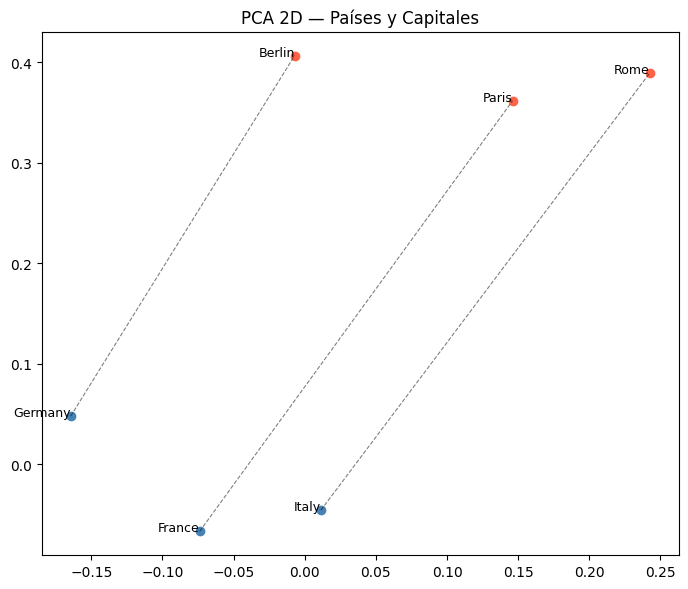

In [9]:
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)
word_to_idx = {w: i for i, w in enumerate(words)}

pairs = [("Italy", "Rome"), ("France", "Paris"), ("Germany", "Berlin")]

fig, ax = plt.subplots(figsize=(7, 6))
for country, capital in pairs:
    ci, cc = word_to_idx[country], word_to_idx[capital]
    ax.scatter(*coords[ci], color="steelblue")
    ax.scatter(*coords[cc], color="tomato")
    ax.annotate(country, coords[ci], fontsize=9, ha="right")
    ax.annotate(capital, coords[cc], fontsize=9, ha="right")
    ax.plot([coords[ci, 0], coords[cc, 0]], [coords[ci, 1], coords[cc, 1]],
            "k--", linewidth=0.8, alpha=0.5)

ax.set_title("PCA 2D — Países y Capitales")
plt.tight_layout()

plt.show()

Los tres segmentos, Italy→Rome, France→Paris y Germany→Berlin, son notablemente paralelos entre sí y de magnitud similar en el plano PCA. Esto constituye la primera evidencia visual de que FastText aprendió la relación "capital de" como una dirección coherente en el espacio de embeddings: los vectores diferencia $\vec{v}(\text{capital}) - \vec{v}(\text{país})$ apuntan esencialmente en la misma dirección para los tres pares, a pesar de haber sido aprendidos de manera no supervisada a partir del contexto estadístico del corpus. La proyección PCA preserva esa estructura porque esa dirección tiene varianza suficiente para quedar representada en los dos ejes dominantes.



Para verificar que la dirección "capital de" es universal y no un artefacto de la proximidad geográfica entre países europeos, se repite la visualización con un par por continente: Alemania (Europa), Brasil (América), Kenia (África), Japón (Asia) y Australia (Oceanía).

Si el modelo capturó correctamente la relación semántica "capital de", entonces el vector diferencia $\vec{v}(\text{capital}) - \vec{v}(\text{país})$ debería ser aproximadamente constante para todos los pares, independientemente del continente. Geométricamente, esto implica que los segmentos que unen cada país con su capital en el espacio de embeddings son vectores casi paralelos y de magnitud similar. Al proyectarlos a 2D con PCA, donde se preserva la estructura de mayor varianza, esa propiedad debería mantenerse: las cinco líneas deberían ser aproximadamente paralelas entre sí.

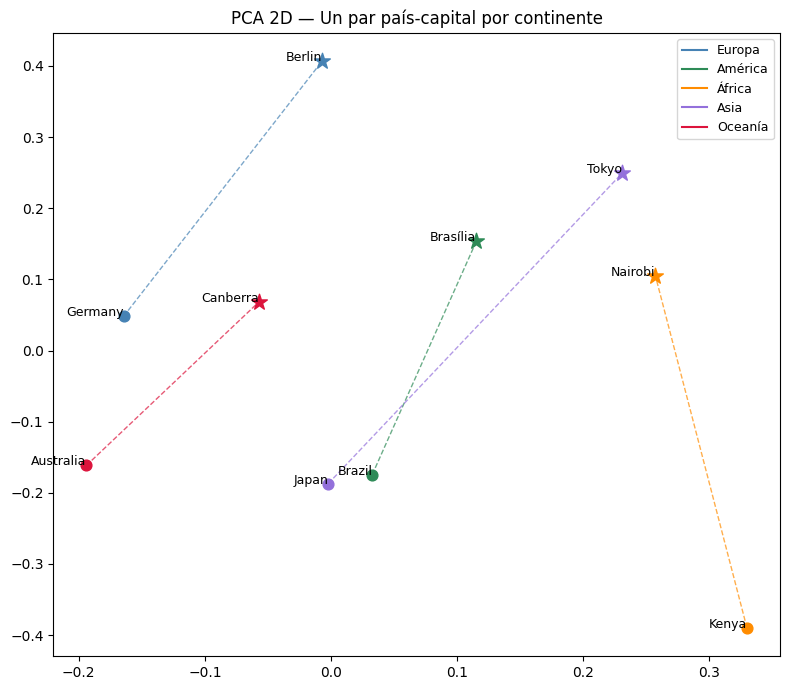

In [10]:
pairs_ext = [
    ("Germany",   "Berlin",   "Europa",  "steelblue"),
    ("Brazil",    "Brasília",  "América", "seagreen"),
    ("Kenya",     "Nairobi",  "África",  "darkorange"),
    ("Japan",     "Tokyo",    "Asia",    "mediumpurple"),
    ("Australia", "Canberra", "Oceanía", "crimson"),
]

fig, ax = plt.subplots(figsize=(8, 7))
legend_handles = []
for country, capital, continent, color in pairs_ext:
    ci, cc = word_to_idx[country], word_to_idx[capital]
    ax.scatter(*coords[ci], color=color, marker="o", s=60, zorder=3)
    ax.scatter(*coords[cc], color=color, marker="*", s=140, zorder=3)
    ax.annotate(country, coords[ci], fontsize=9, ha="right")
    ax.annotate(capital, coords[cc], fontsize=9, ha="right")
    ax.plot([coords[ci, 0], coords[cc, 0]], [coords[ci, 1], coords[cc, 1]],
            "--", color=color, linewidth=1.0, alpha=0.7)
    legend_handles.append(
        plt.Line2D([0], [0], color=color, linewidth=1.5, label=continent)
    )

ax.legend(handles=legend_handles, fontsize=9, loc="best")
ax.set_title("PCA 2D — Un par país-capital por continente")
plt.tight_layout()
plt.show()


La hipótesis se verifica parcialmente. Cuatro de los cinco pares (Europa, América, Asia y Oceanía) exhiben segmentos aproximadamente paralelos, todos orientados en la misma dirección del plano PCA. Esto confirma que FastText aprendió la relación "capital de" como una dirección consistente en el espacio vectorial de 300 dimensiones, generalizable entre continentes y sin dependencia del contexto lingüístico o geográfico de cada par.

La excepción es el par Kenia–Nairobi (África), cuyo segmento apunta en una dirección distinta al resto. Esto es consistente con el sesgo de representación del corpus de entrenamiento: el modelo `cc.en.300.bin` fue entrenado sobre Common Crawl, un rastreo masivo de la web en inglés donde el contenido sobre política y geografía africana aparece menos con respecto al de países europeos, asiáticos o americanos. Como resultado, la relación entre "Kenya" y "Nairobi" no está tan consolidada en el espacio de embeddings como la de "Germany" y "Berlin", lo que se manifiesta en una dirección diferencial desalineada con el resto.

## 2. Sistema de Recomendación de Materias de FIUBA

El mecanismo es el mismo que usan Netflix, Spotify o TikTok: dado lo que un usuario ya calificó, predecir qué otras cosas le van a gustar.

En este caso la señal de preferencia disponible es binaria y proviene directamente del historial académico: el estudiante aprobó la materia (+1) o la reprobó (−1).

La idea clave es que tanto los estudiantes como las materias se representan como vectores en un mismo espacio $\mathbb{R}^d$, son dos nubes de puntos dentro del mismo. El entrenamiento, que arranca con vectores aleatorios, va ajustando ambas nubes simultáneamente hasta que cada par (estudiante, materia) queda alineado si hubo aprobación y opuesto si hubo reprobación. La predicción para una materia no cursada es simplemente el producto escalar $\hat{R}_{ij} = U_i \cdot V_j$: cuanto más alineados estén el vector del estudiante $U_i$ y el de la materia $V_j$, más alta es la predicción.

Un efecto secundario del entrenamiento, al igual que en Word2Vec, es que estudiantes con gustos similares terminan con vectores $U_i$ parecidos sin que nadie se lo haya indicado explícitamente. Esto es lo que permite generalizar: si otro estudiante con un perfil parecido aprobó una materia que vos no cursaste, su $U$ ya empujó ese $V_j$ hacia esa región del espacio, y cuando el modelo evalúa $U_i \cdot V_j$ para vos, el producto escalar resulta alto.


### (a) Análisis Teórico

#### Punto de partida: la matriz de ratings

Toda la información disponible cabe en una única matriz $R \in \mathbb{R}^{m \times n}$, con $m = 70$ estudiantes en las filas y $n = 20$ materias en las columnas. La entrada $R_{ij}$ vale $+1$ si el estudiante $i$ aprobó la materia $j$, $-1$ si la reprobó, y $0$ si todavía no la cursó. Esos ceros no son calificaciones neutras: son entradas ausentes. La máscara binaria:

$$M_{ij} = \mathbf{1}[R_{ij} \neq 0]$$

distingue las entradas observadas de las ausentes. El modelo solo aprende de las primeras; los ceros simplemente no participan en el cálculo del error.

#### Definición del modelo
A cada estudiante $i$ se le asigna un vector $U_i \in \mathbb{R}^d$ y a cada materia $j$ un vector $V_j \in \mathbb{R}^d$. La predicción para el par $(i, j)$ es el producto escalar entre ambos:

$$\hat{R}_{ij} = U_i \cdot V_j$$

La idea es que, al converger, los vectores de un estudiante y una materia que aprobó estén alineados ($U_i \cdot V_j \approx +1$), y los de una materia que reprobó estén opuestos ($U_i \cdot V_j \approx -1$). La predicción para una materia no cursada surge naturalmente de esa geometría aprendida.

En forma matricial, esto equivale a la factorización:

$$\hat{R} = UV^T, \qquad U \in \mathbb{R}^{m \times d}, \quad V \in \mathbb{R}^{n \times d}$$

La dimensión $d$ es el tamaño del espacio latente, o sea, cuántas "dimensiones de preferencia" se le atribuyen a cada estudiante y materia. En este trabajo se usa $d = 5$.

#### La función de costo:

Al principio $U$ y $V$ son aleatorias, por lo que $\hat{R}_{ij}$ no predice nada útil. El entrenamiento las ajusta minimizando el error cuadrático sobre las entradas observadas únicamente, más una penalización que evita que los vectores crezcan indefinidamente, es la misma regularización L2 del TPS2:

$$\mathcal{L}(U, V) = \underbrace{\sum_{(i,j):\,M_{ij}=1} (R_{ij} - U_i \cdot V_j)^2}_{\text{error en entradas observadas}} + \lambda \underbrace{\left(\|U\|_F^2 + \|V\|_F^2\right)}_{\text{regularización L2}}$$

Sin la regularización, $U$ y $V$ crecerían hasta reproducir exactamente cada $R_{ij}$ observado, pero las predicciones para materias no cursadas serían inestables. $\lambda$ frena ese crecimiento forzando un balance entre ajustar bien los datos disponibles y mantener los vectores pequeños.

Para calcular los gradientes de forma eficiente, conviene introducir la matriz de error enmascarado $E$. La idea es sencilla: se calcula el error de predicción para todas las celdas de la matriz y luego se ponen en cero las que no tienen dato. Formalmente:

$$E = M \odot (R - UV^T)$$

donde $\odot$ es el producto elemento a elemento. El resultado es una matriz $70 \times 20$ donde las celdas observadas contienen el error real $(R_{ij} - U_i \cdot V_j)$ y las no observadas son exactamente $0$. Con eso, la sumatoria sobre entradas observadas se convierte en una norma de Frobenius:

$$\mathcal{L} = \|E\|_F^2 + \lambda\left(\|U\|_F^2 + \|V\|_F^2\right)$$

que es idéntica a la expresión anterior pero en forma matricial, sin el símbolo de sumatoria.
#### Los gradientes

Para minimizar $\mathcal{L}$ por gradiente descendente se necesita saber en qué dirección mover cada vector. La lógica es la misma que en Word2Vec: cuando el estudiante $i$ aprobó la materia $j$ pero los vectores aún no están alineados, el error $E_{ij}$ es grande y positivo, y el gradiente empuja $U_i$ hacia $V_j$ y $V_j$ hacia $U_i$ simultáneamente. Si la calificación fue negativa y los vectores están alineados, el error es negativo y los aleja. Los jalones son proporcionales al error: fuerte cuando se está lejos, casi nulo cuando se está cerca.

**Gradiente respecto de $U$.** Derivando $\mathcal{L}$ respecto de la fila $U_i$:

$$\frac{\partial \mathcal{L}}{\partial U_i} = -2 \sum_{j:\,M_{ij}=1} \underbrace{(R_{ij} - U_i \cdot V_j)}_{E_{ij}} \cdot V_j + 2\lambda\, U_i$$

El primer término acumula los jalones de todas las materias cursadas por el estudiante $i$, ponderados por el error. Apilando todas las filas:

$$\boxed{\nabla_U \mathcal{L} = -2\, E\, V + 2\lambda\, U}$$

**Gradiente respecto de $V$.** Por la simetría de la factorización, el gradiente para la materia $j$ tiene exactamente la misma estructura con los roles de $U$ y $V$ intercambiados:

$$\frac{\partial \mathcal{L}}{\partial V_j} = -2 \sum_{i:\,M_{ij}=1} E_{ij} \cdot U_i + 2\lambda\, V_j$$

$$\boxed{\nabla_V \mathcal{L} = -2\, E^T U + 2\lambda\, V}$$

Reemplazando $E$ por $E^T$ y $V$ por $U$ en la primera fórmula se obtiene exactamente la segunda. Esa simetría se traslada directamente al código: el paso de gradiente descedente se implementa en dos líneas idénticas.


### (b) Preprocesamiento

Se carga el archivo `TA136.csv`, que contiene las calificaciones de 70 estudiantes sobre 20 materias. Los valores 1.0 se mapean a $+1$ (calificación positiva), 0.0 a $-1$ (negativa), y los campos vacíos a $0$ (no calificado). A continuación se incorpora un estudiante ficticio con 15 materias calificadas.

In [11]:
DATA_CSV = "TA136.csv"
DATA_URL = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/TA136.csv"

if not os.path.exists(DATA_CSV):
    urllib.request.urlretrieve(DATA_URL, DATA_CSV)

SUBJECTS = [
    "Análisis Matemático I",        # 0
    "Álgebra",                       # 1
    "Física I",                      # 2
    "Algoritmos y Programación",     # 3
    "Análisis Matemático II",        # 4
    "Física II",                     # 5
    "Análisis Numérico",             # 6
    "Probabilidad y Estadística",    # 7
    "Circuitos Eléctricos",          # 8
    "Electrónica I",                 # 9
    "Señales y Sistemas",            # 10
    "Electrónica II",                # 11
    "Teoría de Control",             # 12
    "Comunicaciones",                # 13
    "Procesamiento de Señales",      # 14
    "Máquinas Eléctricas",           # 15
    "Electrónica de Potencia",       # 16
    "Microelectrónica",              # 17
    "Arquitectura de Computadoras",  # 18
    "Laboratorio de Electrónica",    # 19
]

df_raw = pd.read_csv(DATA_CSV, index_col=0)
df_raw.columns = SUBJECTS

R_raw = df_raw.values                                                          # (70, 20), puede contener NaN
R = np.where(np.isnan(R_raw), 0.0, np.where(R_raw == 1.0, 1.0, -1.0))        # +1 / -1 / 0
M = (~np.isnan(R_raw)).astype(float)                                           # máscara de entradas observadas

# Estudiante ficticio: perfil teórico-matemático, orientado a señales y sistemas
# Calificados (15): ítems 0–14  |  Sin calificar (5): ítems 15–19
invented = np.array([
     1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
     1, -1,  1,  1,  1,  0,  0,  0,  0,  0
], dtype=float)

R_full = np.vstack([R, invented])
M_full = np.vstack([M, (invented != 0).astype(float)])

print(f"Matriz de ratings: {R_full.shape}  ({int(M_full.sum())} entradas calificadas en total)\n")

print(f"Estudiante ficticio: {int(M_full[-1].sum())} materias calificadas:")
for name, val in zip(SUBJECTS, invented):
    if val != 0:
        print(f"  [{'+ 1' if val == 1 else '- 1'}]  {name}")
print("\nMaterias sin calificar (candidatas a recomendación):")
for name, val in zip(SUBJECTS, invented):
    if val == 0:
        print(f"  [   ]  {name}")


Matriz de ratings: (71, 20)  (1281 entradas calificadas en total)

Estudiante ficticio: 15 materias calificadas:
  [+ 1]  Análisis Matemático I
  [+ 1]  Álgebra
  [+ 1]  Física I
  [- 1]  Algoritmos y Programación
  [+ 1]  Análisis Matemático II
  [+ 1]  Física II
  [+ 1]  Análisis Numérico
  [+ 1]  Probabilidad y Estadística
  [+ 1]  Circuitos Eléctricos
  [- 1]  Electrónica I
  [+ 1]  Señales y Sistemas
  [- 1]  Electrónica II
  [+ 1]  Teoría de Control
  [+ 1]  Comunicaciones
  [+ 1]  Procesamiento de Señales

Materias sin calificar (candidatas a recomendación):
  [   ]  Máquinas Eléctricas
  [   ]  Electrónica de Potencia
  [   ]  Microelectrónica
  [   ]  Arquitectura de Computadoras
  [   ]  Laboratorio de Electrónica


**Perfil del estudiante ficticio.** Se trata de un estudiante de Ingeniería Eléctrica con fuerte inclinación por las materias teóricas y matemáticas. Califica positivamente el eje continuo del plan de estudios orientado a la teoría de sistemas: análisis matemático, álgebra, física, probabilidad y estadística, señales y sistemas, análisis numérico, circuitos eléctricos, teoría de control, comunicaciones y procesamiento de señales. Califica negativamente algoritmos y programación y las materias de electrónica analógica (Electrónica I y II). No ha cursado aún las materias del área de potencia (Máquinas Eléctricas, Electrónica de Potencia) ni las de hardware y sistemas (Microelectrónica, Arquitectura de Computadoras, Laboratorio de Electrónica): estas cinco son las candidatas a recomendar. El perfil es internamente consistente: las calificaciones positivas y negativas responden a una preferencia coherente por la teoría sobre la práctica.

**Nota sobre la consistencia del perfil.** El filtro colaborativo no tiene acceso al plan de estudios ni a las correlativas: la única información que utiliza es la matriz $R$, es decir, quién aprobó qué y quién reprobó qué.

### (c) Entrenamiento

Se implementa el filtro colaborativo por gradiente descendente usando los gradientes derivados en (a). En cada iteración se calculan las matrices de error enmascarado $E$ y se actualizan $U$ y $V$ simultáneamente. El entrenamiento se realiza con un espacio de dimensión $d = 5$ (es decir, 5 *features*).

A diferencia de la etapa de hold-out, donde se entrenará sobre el 80% de las entradas para evaluar la generalización, acá se utilizará la máscara completa `M_full`, es decir, el 100% de las entradas observadas. Una vez seleccionado λ, ya no habrá necesidad de reservar un conjunto de validación: el modelo final aprovechará toda la información disponible.

Los valores $\alpha = 0.005$ y $N = 1000$ *epochs* se fijan de manera arbitraria como punto de partida. La idoneidad de ambos se evaluará a partir de la curva de convergencia: un $\alpha$ demasiado grande produciría oscilaciones o divergencia, y uno demasiado pequeño haría que 1000 *epochs* resulten insuficientes para alcanzar el plateau. Si la curva desciende suavemente y se estabiliza claramente antes de la última iteración, ambas elecciones quedan validadas.


In [16]:
def train_cf(R, M, d=5, alpha=0.005, lam=0.05, n_epochs=1000, seed=17):
    """Filtro colaborativo por gradiente descendente.

    Parámetros
    ----------
    R        : (m, n) matriz de ratings (+1 / -1 / 0)
    M        : (m, n) máscara binaria (1 donde hay calificación)
    d        : dimensión del espacio latente
    alpha    : learning rate
    lam      : coeficiente de regularización L2
    n_epochs : número de iteraciones
    """
    m, n = R.shape
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 0.1, (m, d))
    V = rng.normal(0, 0.1, (n, d))

    losses = []
    for _ in range(n_epochs):
        E = M * (R - U @ V.T)                             # error enmascarado (m, n)
        loss = np.sum(E**2) + lam * (np.sum(U**2) + np.sum(V**2))
        losses.append(loss)
        grad_U = -2 * E @ V + 2 * lam * U                # (m, d)
        grad_V = -2 * E.T @ U + 2 * lam * V              # (n, d)
        U -= alpha * grad_U
        V -= alpha * grad_V

    return U, V, np.array(losses)


#### Selección de λ por hold-out

Antes de fijar λ, se evalúa su efecto sobre la capacidad de generalización del modelo. La estrategia es análoga a la usada en regresión regularizada (TP2): se enmascara el 20% de las entradas observadas como conjunto de validación, se entrena con el 80% restante para varios valores de λ, y se mide el MSE de reconstrucción sobre las entradas ocultas.

Para interpretar los resultados conviene tener presente qué haría un modelo sin información: como todos los ratings son exactamente +1 o −1, un modelo que predice $\hat{R}_{ij} = 0$ en todas las entradas obtiene un error de $(±1 - 0)^2 = 1$ en cada posición, es decir, MSE = 1.0. Ese es el piso de referencia: no implica ningún aprendizaje, simplemente refleja que los datos son binarios y centrados en cero. Cualquier modelo útil debe bajar de ese umbral.

Con λ demasiado grande, todos los vectores se encogen hacia cero y las predicciones se acercan a cero en magnitud. Pero "cerca de cero" no es lo mismo que "correcto": si el modelo predice un valor pequeño pero negativo para una entrada que vale +1, el error es $(+1 - (-\epsilon))^2 > 1$, peor que si hubiera predicho 0. Ese es el sentido en que λ excesivo puede superar el MSE del modelo nulo.

El λ óptimo equilibra ambos extremos: regularización suficiente para no sobreajustar el 80% de entrenamiento, pero no tanta como para que las predicciones pierdan dirección. Se busca en el rango $[10^{-3},\, 50]$ y se elige el valor que minimiza el MSE de validación.

  λ = 0.001   val MSE = 2.4970
  λ = 0.01    val MSE = 2.4437
  λ = 0.05    val MSE = 2.2511
  λ = 0.1     val MSE = 2.0771
  λ = 0.5     val MSE = 1.4342
  λ = 1.0     val MSE = 1.2412
  λ = 2.0     val MSE = 1.0074
  λ = 5.0     val MSE = 0.8266
  λ = 10.0    val MSE = 0.8778
  λ = 20.0    val MSE = 1.0000
  λ = 50.0    val MSE = 1.0000

→ λ óptimo: 5.0  (val MSE = 0.8266)


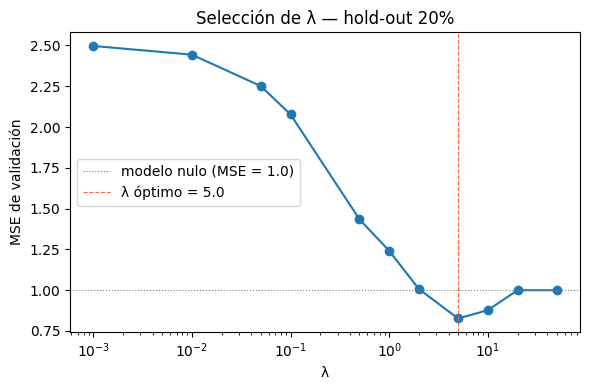

In [18]:
# Selección de λ por hold-out: se enmascara el 20% de las entradas observadas
rng_val = np.random.default_rng(0)
obs_idx = np.argwhere(M_full == 1)
n_val   = int(0.2 * len(obs_idx))
val_pos = rng_val.choice(len(obs_idx), size=n_val, replace=False)

M_train = M_full.copy()
for i, j in obs_idx[val_pos]:
    M_train[i, j] = 0.0

lambdas    = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
val_errors = []

for lam in lambdas:
    U_v, V_v, _ = train_cf(R_full, M_train, d=5, alpha=0.005, lam=lam, n_epochs=1000, seed=42)
    R_hat_v  = U_v @ V_v.T
    val_mse  = np.mean([(R_full[i, j] - R_hat_v[i, j])**2 for i, j in obs_idx[val_pos]])
    val_errors.append(val_mse)
    print(f"  λ = {lam:<6}  val MSE = {val_mse:.4f}")

best_lam = lambdas[np.argmin(val_errors)]
print(f"\n→ λ óptimo: {best_lam}  (val MSE = {min(val_errors):.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambdas, val_errors, "o-")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, label="modelo nulo (MSE = 1.0)")
ax.axvline(best_lam, color="tomato", linestyle="--", linewidth=0.8, label=f"λ óptimo = {best_lam}")
ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("MSE de validación")
ax.set_title("Selección de λ — hold-out 20%")
ax.legend()
plt.tight_layout()
plt.show()


**Análisis de la selección de λ.** La curva de MSE de validación exhibe la forma de U característica del balance sesgo-varianza, con mínimo en λ = 5.0 (MSE = 0.8266).

Para λ pequeño (0.001–0.1), el modelo sobreajusta las entradas de entrenamiento: aprende con precisión los patrones del 80%, pero las predicciones sobre el 20% oculto son ruidosas y el MSE supera 2.0. A medida que λ crece, la regularización encoge los vectores y el modelo generaliza mejor.

En λ = 2.0 el MSE es 1.0074, levemente por encima de 1.0. Este valor es el del modelo nulo (predecir 0 en todas las entradas): como todos los ratings son exactamente ±1, predecir 0 da un error de $(±1)^2 = 1$ en cada posición. Que λ = 2.0 supere ese umbral indica que el modelo produce predicciones pequeñas pero en la dirección equivocada para parte del conjunto de validación, que es peor que no predecir nada.

En λ = 5.0, el MSE alcanza su mínimo global de 0.8266, un 17% por debajo del modelo nulo. Los vectores son lo suficientemente pequeños como para no sobreajustar, pero aún apuntan en la dirección correcta para la mayoría de las entradas ocultas.

Para λ ≥ 20, el MSE converge exactamente a 1.0000: los vectores colapsan hacia cero y las predicciones son indistinguibles de cero, replicando el comportamiento del modelo nulo. El valor exacto 1.0000 confirma la cobertura completa de la búsqueda: el modelo degeneró hasta el piso teórico.

Con el valor de $\lambda$ decidido, se procede a realizar el entrenamiento.

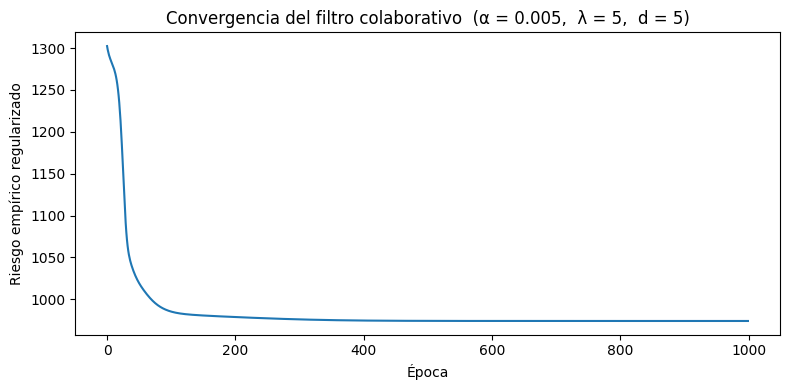

Pérdida inicial:  1302.42
Pérdida final:    974.04
Reducción:        25.2%

Top-3 materias no calificadas para 3 usuarios distintos (λ = 5):
  Usuario  0: Circuitos Eléctricos, Algoritmos y Programación
  Usuario 10: Análisis Numérico, Álgebra
  Usuario 24: Comunicaciones, Electrónica de Potencia


In [25]:


ALPHA    = 0.005
LAM      = 5
N_EPOCHS = 1000

U, V, losses = train_cf(R_full, M_full, d=5, alpha=ALPHA, lam=LAM, n_epochs=N_EPOCHS)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses)
ax.set_xlabel("Época")
ax.set_ylabel("Riesgo empírico regularizado")
ax.set_title(f"Convergencia del filtro colaborativo  (α = {ALPHA},  λ = {LAM},  d = 5)")
plt.tight_layout()
plt.show()

print(f"Pérdida inicial:  {losses[0]:.2f}")
print(f"Pérdida final:    {losses[-1]:.2f}")
print(f"Reducción:        {100*(1 - losses[-1]/losses[0]):.1f}%\n")

# Verificación: con λ > 0 las recomendaciones difieren entre usuarios
R_hat = U @ V.T
print(f"Top-3 materias no calificadas para 3 usuarios distintos (λ = {LAM}):")
for user_idx in [0, 10, 24]:
    unrated = np.where(M_full[user_idx] == 0)[0]
    top3    = unrated[np.argsort(R_hat[user_idx, unrated])[::-1][:3]]
    names   = ", ".join(SUBJECTS[i] for i in top3)
    print(f"  Usuario {user_idx:>2}: {names}")

**Análisis del entrenamiento.** La pérdida disminuyó de 1302.42 a 974.04, una reducción del 25.2%. La reducción es menor que la que se obtendría con λ pequeño (con λ = 0.05 la misma métrica cae un 62.2%) porque el término de regularización λ‖U‖² + λ‖V‖² contribuye significativamente al valor de la pérdida: vectores pequeños implican menor error de reconstrucción pero mayor penalización, y el mínimo del riesgo regularizado se alcanza con vectores más contenidos.

La curva de convergencia valida retroactivamente la elección arbitraria de $\alpha = 0.005$ y $N = 1000$ *epochs*. La curva es monótonamente decreciente sin oscilaciones, lo que confirma que $\alpha$ está en el régimen estable. El aplanamiento se alcanza claramente antes de la *epoch* 200.

La verificación sobre tres usuarios confirma que el filtro produce recomendaciones diferenciadas: los usuarios los 3 reciben conjuntos distintos de materias.

### (d) Rating

El filtro colaborativo predice $\hat{R}_{ij} = U_i \cdot V_j$ para cada par (estudiante, materia). Esta predicción es personalizada, pero con un dataset pequeño puede ser ruidosa: si pocos estudiantes similares al usuario $i$ cursaron la materia $j$, el modelo tiene poca información para respaldar ese número.

Para estabilizar las recomendaciones se introduce la calificación media de cada materia:

$$\bar{R}_j = \frac{\sum_{i:\,M_{ij}=1} R_{ij}}{\sum_{i} M_{ij}}$$

que es el promedio de los $\pm 1$ de todos los estudiantes que cursaron la materia $j$. Un valor cercano a $+1$ indica que la gran mayoría la aprobó (materia accesible o bien recibida); cercano a $-1$, que la mayoría la reprobó (materia difícil o de alto rechazo). Esta media es una señal global estable: no depende del perfil de nadie en particular y se calcula directamente sobre los datos observados.

El **rating final** mezcla ambas señales mediante el hiperparámetro $p \in [0,1]$:

$$\text{rating}(i, j) = p \cdot \hat{R}_{ij} + (1-p)\cdot \bar{R}_j$$

- $p = 1$: completamente personalizado, sin ancla global.
- $p = 0$: popularidad pura, recomienda lo mismo a todos.
- $p \in (0,1)$: mezcla. La media actúa como regularizador sobre la recomendación misma.

Se elige $p = 0.7$: el 70% del peso sigue siendo personal y el 30% proviene de la tendencia global.

In [26]:
P = 0.7

# Calificación media por materia (sobre entradas observadas solamente)
mean_per_subject = np.where(
    M_full.sum(axis=0) > 0,
    (R_full * M_full).sum(axis=0) / M_full.sum(axis=0),
    0.0
)

# Rating combinado: p * CF + (1-p) * media global
R_hat  = U @ V.T
RATING = P * R_hat + (1 - P) * mean_per_subject[np.newaxis, :]

# Recomendaciones para el estudiante ficticio (última fila)
student_idx = len(R_full) - 1
unrated_idx = np.where(M_full[student_idx] == 0)[0]

top5_idx = unrated_idx[np.argsort(RATING[student_idx, unrated_idx])[::-1][:5]]

print(f"Top-5 recomendaciones — estudiante ficticio  (p = {P}):\n")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  {rank}. {SUBJECTS[idx]:<35}  rating = {RATING[student_idx, idx]:+.4f}")

# Comparación con p = 1.0
RATING_p1 = 1.0 * R_hat
top5_p1   = unrated_idx[np.argsort(RATING_p1[student_idx, unrated_idx])[::-1][:5]]

print(f"\nComparación con p = 1.0:\n")
for rank, idx in enumerate(top5_p1, 1):
    print(f"  {rank}. {SUBJECTS[idx]:<35}  rating = {RATING_p1[student_idx, idx]:+.4f}")

# Media por materia candidata (referencia)
print(f"\nMedia de calificaciones por materia candidata:")
for idx in sorted(unrated_idx):
    print(f"  {SUBJECTS[idx]:<35}  media = {mean_per_subject[idx]:+.4f}")

Top-5 recomendaciones — estudiante ficticio  (p = 0.7):

  1. Microelectrónica                     rating = +0.5757
  2. Arquitectura de Computadoras         rating = +0.4978
  3. Electrónica de Potencia              rating = +0.2975
  4. Laboratorio de Electrónica           rating = +0.2126
  5. Máquinas Eléctricas                  rating = -0.3292

Comparación con p = 1.0 (CF puro):

  1. Arquitectura de Computadoras         rating = +0.5727
  2. Microelectrónica                     rating = +0.5320
  3. Laboratorio de Electrónica           rating = +0.3836
  4. Electrónica de Potencia              rating = +0.3679
  5. Máquinas Eléctricas                  rating = -0.1196

Media de calificaciones por materia candidata:
  Máquinas Eléctricas                  media = -0.8182
  Electrónica de Potencia              media = +0.1333
  Microelectrónica                     media = +0.6774
  Arquitectura de Computadoras         media = +0.3231
  Laboratorio de Electrónica           media = -

Con $p = 0.7$, el sistema recomienda en orden: Microelectrónica ($+0.576$), Arquitectura de Computadoras ($+0.498$), Electrónica de Potencia ($+0.298$), Laboratorio de Electrónica ($+0.213$) y Máquinas Eléctricas ($-0.329$). El resultado es coherente con el perfil construido: las dos materias mejor posicionadas son teóricas y de electrónica digital, alineadas con el historial de aprobación del estudiante (señales, control, matemática), mientras que Máquinas Eléctricas (la más alejada de ese perfil) queda última con rating negativo.

El ranking cambia respecto de $p = 1.0$, donde Arquitectura encabezaba la lista y Laboratorio de Electrónica aparecía tercera. El desplazamiento se explica directamente por las medias globales: Microelectrónica tiene la media más alta del conjunto ($\bar{R} = +0.677$), por lo que el 30% global la impulsa por encima de Arquitectura ($\bar{R} = +0.323$). Laboratorio de Electrónica baja de tercer a cuarto lugar porque su media es negativa ($\bar{R} = -0.186$): aunque el personal la valoraba bien, la tendencia global la penaliza. El caso opuesto se observa en Máquinas Eléctricas: su media es la más baja del conjunto ($\bar{R} = -0.818$) y arrastra su rating desde $-0.120$ hasta $-0.329$.

El hecho de que el orden difiera entre $p = 0.7$ y $p = 1.0$ confirma que $\bar{R}_j$ aporta información discriminativa: las medias de las candidatas no son uniformes y su incorporación modifica las recomendaciones de manera interpretable. El hiperparámetro $p$ cumple su función como balance entre señal personal y señal global.